In [159]:
print("Hello World")

Hello World


## Package import

In [160]:
# ============================================================
# 🔧 SYSTEM & UTILITIES
# ============================================================
import os
import gc
import re
import io
import psutil
import json
import joblib
import pickle
import random
import requests
import itertools
import warnings
import holidays
import urllib.request as urlreq
from tqdm import tqdm
from dotenv import load_dotenv
from datetime import datetime, timedelta, date
from dateutil.relativedelta import relativedelta

# Suppress warnings
warnings.filterwarnings('ignore')

# ============================================================
# 📦 CORE PYTHON & DATA HANDLING
# ============================================================
import numpy as np
import pandas as pd
import datetime as dt

# ============================================================
# 📊 EXPLORATORY DATA ANALYSIS (EDA) & VISUALIZATION
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import missingno as msno
from pandas.plotting import lag_plot, autocorrelation_plot
from scipy import stats
from math import sqrt
from IPython.display import display, HTML

# Enable inline plotting
%matplotlib inline

# ============================================================
# ⚙️ DATA PREPROCESSING & FEATURE ENGINEERING
# ============================================================
from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler, OneHotEncoder, LabelEncoder, PolynomialFeatures
)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest, f_classif
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# ============================================================
# 🧠 MACHINE LEARNING MODELS
# ============================================================
from sklearn.model_selection import (
    train_test_split, TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score, make_scorer
)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# ============================================================
# 🔮 TIME SERIES & FORECASTING
# ============================================================
from statsmodels.tsa.api import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ============================================================
# 🧬 DEEP LEARNING (TENSORFLOW / KERAS)
# ============================================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, Bidirectional, BatchNormalization,
    Conv1D, MaxPooling1D, Flatten
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from tensorflow.keras.utils import plot_model
from tensorflow.keras import backend as K
import keras_tuner as kt

# ============================================================
# 🧮 STATISTICAL ANALYSIS
# ============================================================
import scipy.stats as stats
from scipy.stats import zscore, pearsonr, spearmanr

# ============================================================
# 🗂 DASHBOARDING & FRONT-END (OPTIONAL)
# ============================================================
import streamlit as st

# ============================================================
# ✅ SETUP COMPLETE
# ============================================================
print("✅ All essential libraries imported successfully.")


✅ All essential libraries imported successfully.


## Data Loader

In [161]:
df = pd.read_csv(r'C:\Users\TPWODL\New folder_Content\DeepLearning_TimeSeries_LSTM_End_To_End\data\raw\Energy Demand Hourly.csv')

In [162]:
df

,date,megawatthours
0,01-07-2015 05:00,162827
1,01-07-2015 06:00,335153
2,01-07-2015 07:00,333837
3,01-07-2015 08:00,398386
4,01-07-2015 09:00,388954
...,...,...
58931,21-03-2022 16:00,433344
58932,21-03-2022 17:00,429156
58933,21-03-2022 18:00,426496
58934,21-03-2022 19:00,423393


## Data core checking and cleaning

In [163]:
# -----------------------------------------------
# 1️⃣ Basic Information
# -----------------------------------------------
print("🔹 Dataset Shape:", df.shape)
print("\n🔹 Data Types:")
print(df.dtypes)
print("\n🔹 Columns:", df.columns.tolist())

🔹 Dataset Shape: (58936, 2)

🔹 Data Types:
date             object
megawatthours     int64
dtype: object

🔹 Columns: ['date', 'megawatthours']


In [164]:
# -----------------------------------------------
# 2️⃣ Missing Values & Duplicates
# -----------------------------------------------
print("\n🔹 Missing Values Count:")
print(df.isnull().sum())

print("\n🔹 Duplicate Rows:", df.duplicated().sum())


🔹 Missing Values Count:
date             0
megawatthours    0
dtype: int64

🔹 Duplicate Rows: 0



🔹 Missing Values Count:
date             0
megawatthours    0
dtype: int64

🔹 Duplicate Rows: 0


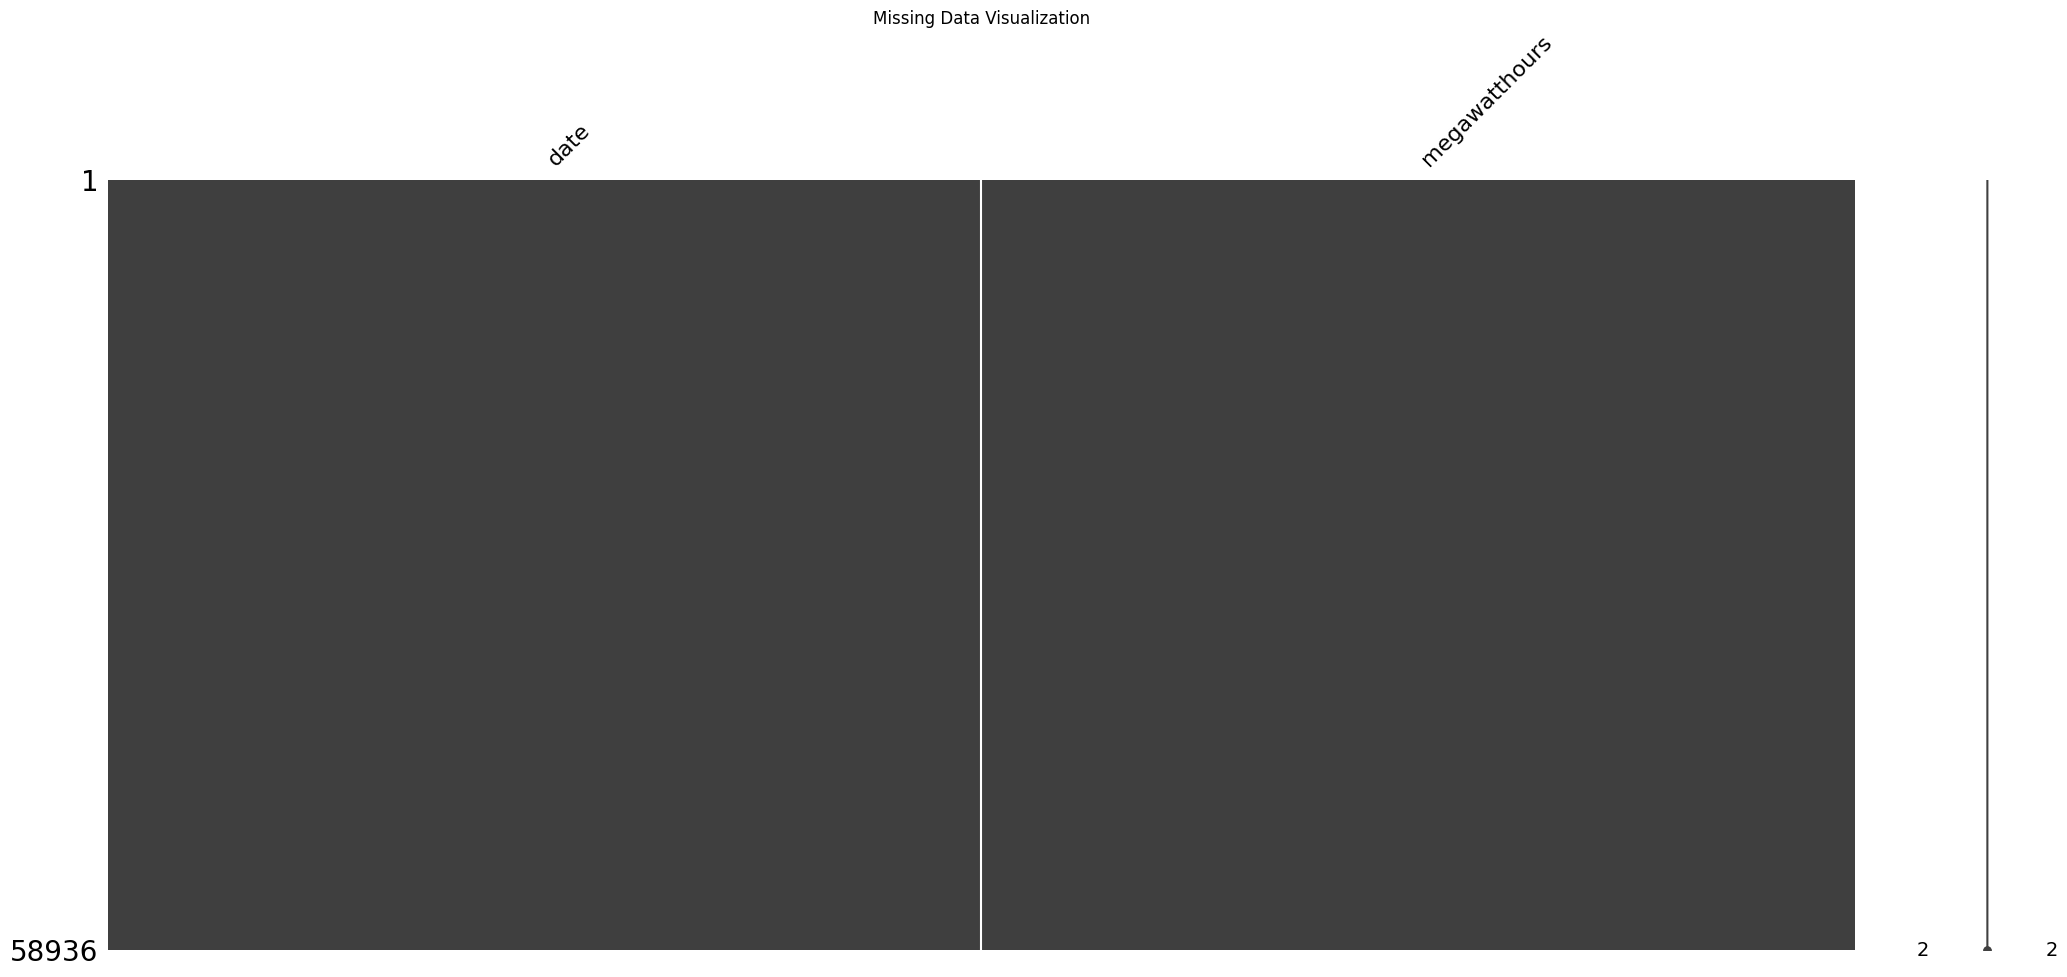

In [165]:
# -----------------------------------------------
# 2️⃣ Missing Values & Duplicates
# -----------------------------------------------
print("\n🔹 Missing Values Count:")
print(df.isnull().sum())

print("\n🔹 Duplicate Rows:", df.duplicated().sum())

# Missing data visualization
msno.matrix(df)
plt.title("Missing Data Visualization")
plt.show()

In [166]:
# -----------------------------------------------
# 3️⃣ Descriptive Statistics
# -----------------------------------------------
print("\n🔹 Summary Statistics:")
df.describe().T


🔹 Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
megawatthours,58936.0,455225.233032,74804.550019,162827.0,403987.0,443225.0,491449.0,719649.0


##### Data distribution can be checked using visualizations like histograms, density plots, and box plots to understand patterns, central tendency, and outliers

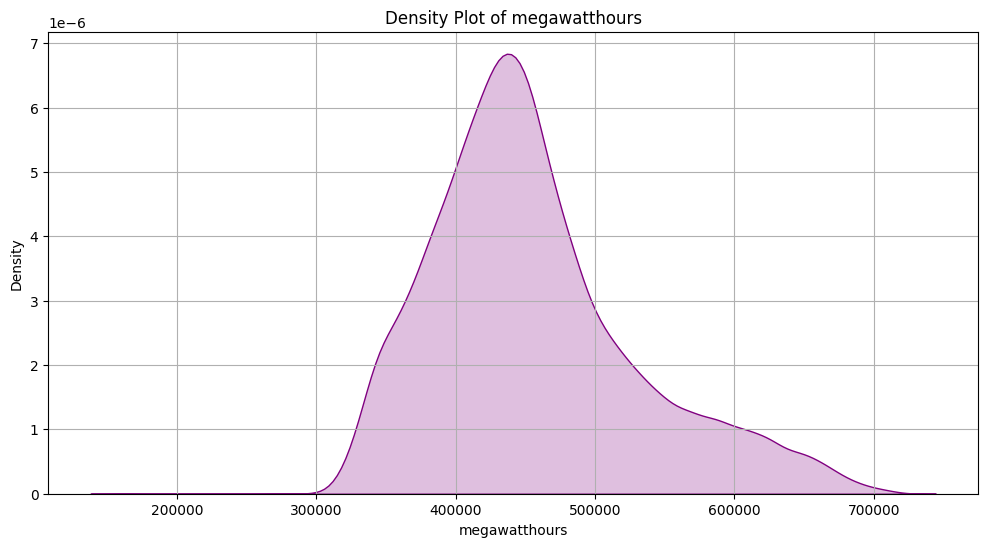

In [167]:
# Loop through each column and plot KDE
plt.figure(figsize=(12, 6))
sns.kdeplot(df['megawatthours'], shade=True, color='purple')
plt.title(f'Density Plot of megawatthours')
plt.xlabel('megawatthours')
plt.ylabel('Density')
plt.grid(True)
plt.show()

### histograms

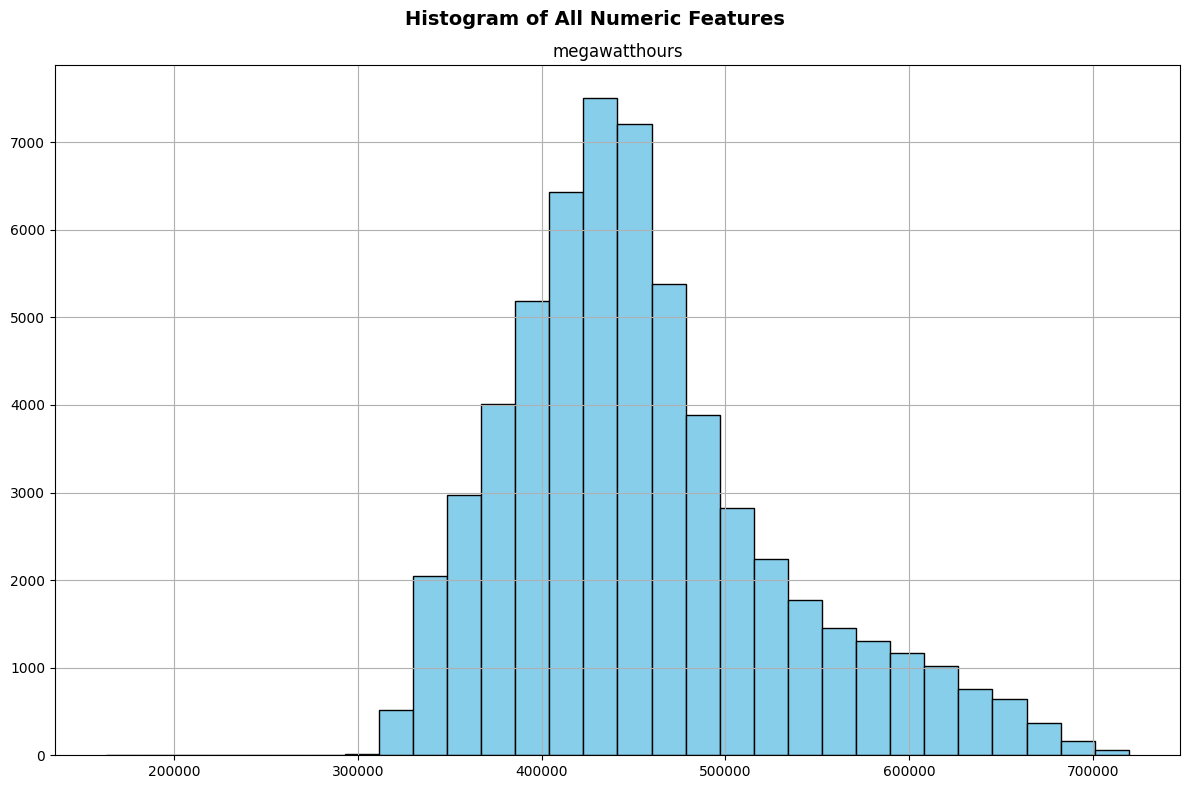

In [168]:
df.hist(figsize=(12, 8), bins=30, color='skyblue', edgecolor='black')
plt.suptitle("Histogram of All Numeric Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [169]:
# Core Data Check / Validation
print("🔍 Core Data Validation")
print("Shape:", df.shape)
print("Data Types:\n", df.dtypes)
print("Missing Values:\n", df.isnull().sum())
print("Duplicate Rows:", df.duplicated().sum())
print("Columns Names", df.columns)

🔍 Core Data Validation
Shape: (58936, 2)
Data Types:
 date             object
megawatthours     int64
dtype: object
Missing Values:
 date             0
megawatthours    0
dtype: int64
Duplicate Rows: 0
Columns Names Index(['date', 'megawatthours'], dtype='object')


#### to_datetime

In [170]:
# Ensure datetime is parsed
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y %H:%M', errors='coerce')

In [171]:
df

,date,megawatthours
0,2015-07-01 05:00:00,162827
1,2015-07-01 06:00:00,335153
2,2015-07-01 07:00:00,333837
3,2015-07-01 08:00:00,398386
4,2015-07-01 09:00:00,388954
...,...,...
58931,2022-03-21 16:00:00,433344
58932,2022-03-21 17:00:00,429156
58933,2022-03-21 18:00:00,426496
58934,2022-03-21 19:00:00,423393


### Core time features

In [172]:
# ===== CORE TIME FEATURES =====
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['day_of_month'] = df['date'].dt.day
df['day_of_year'] = df['date'].dt.dayofyear

In [173]:
df

,date,megawatthours,hour,day_of_week,day_of_month,day_of_year
0,2015-07-01 05:00:00,162827,5,2,1,182
1,2015-07-01 06:00:00,335153,6,2,1,182
2,2015-07-01 07:00:00,333837,7,2,1,182
3,2015-07-01 08:00:00,398386,8,2,1,182
4,2015-07-01 09:00:00,388954,9,2,1,182
...,...,...,...,...,...,...
58931,2022-03-21 16:00:00,433344,16,0,21,80
58932,2022-03-21 17:00:00,429156,17,0,21,80
58933,2022-03-21 18:00:00,426496,18,0,21,80
58934,2022-03-21 19:00:00,423393,19,0,21,80


In [174]:
df.columns

Index(['date', 'megawatthours', 'hour', 'day_of_week', 'day_of_month',
       'day_of_year'],
      dtype='object')

#### EDA Analysis

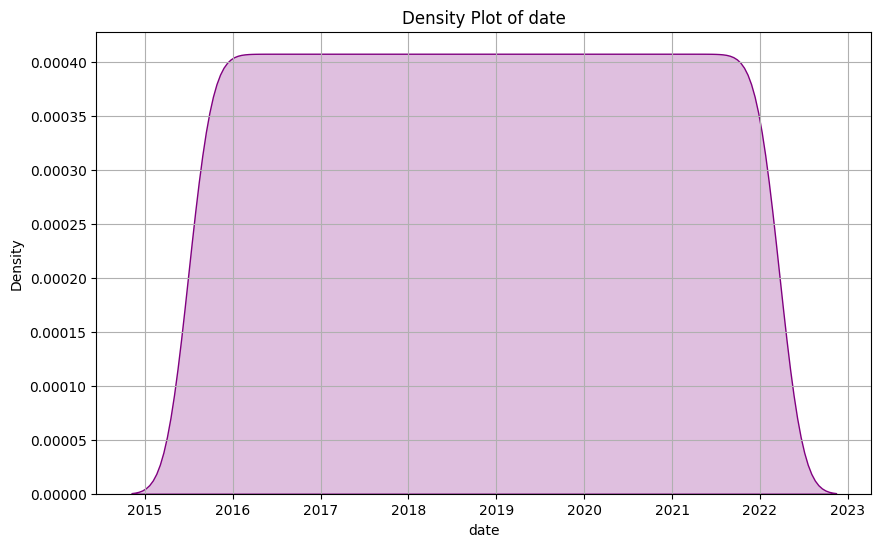

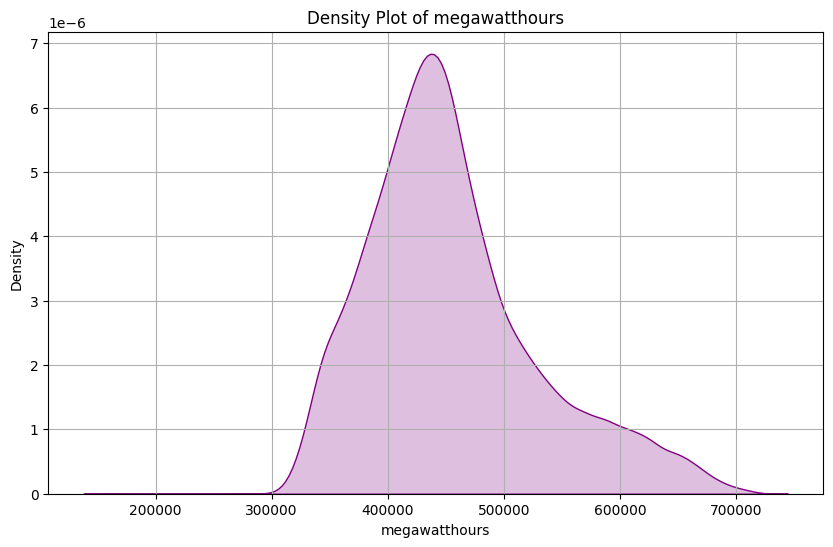

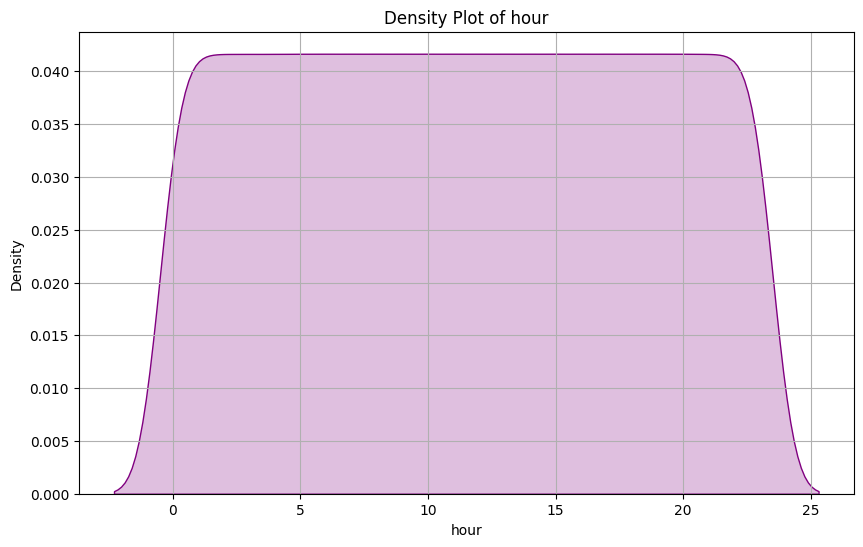

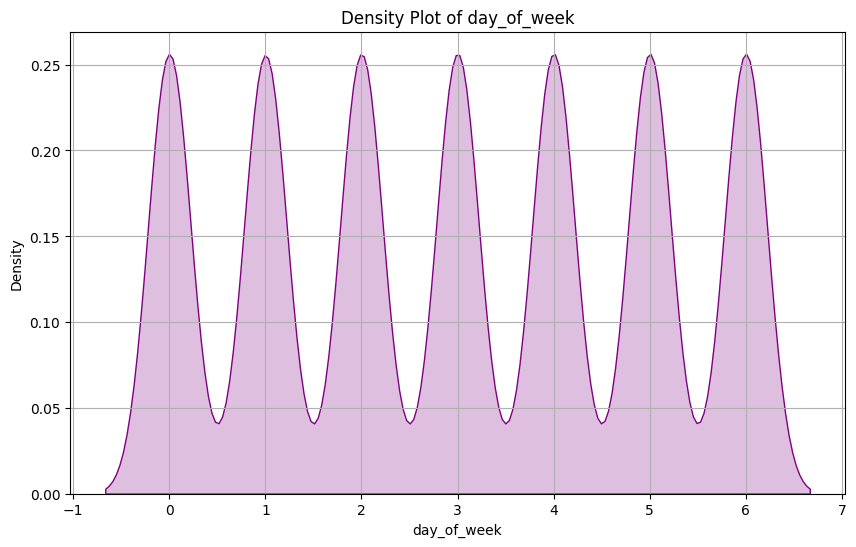

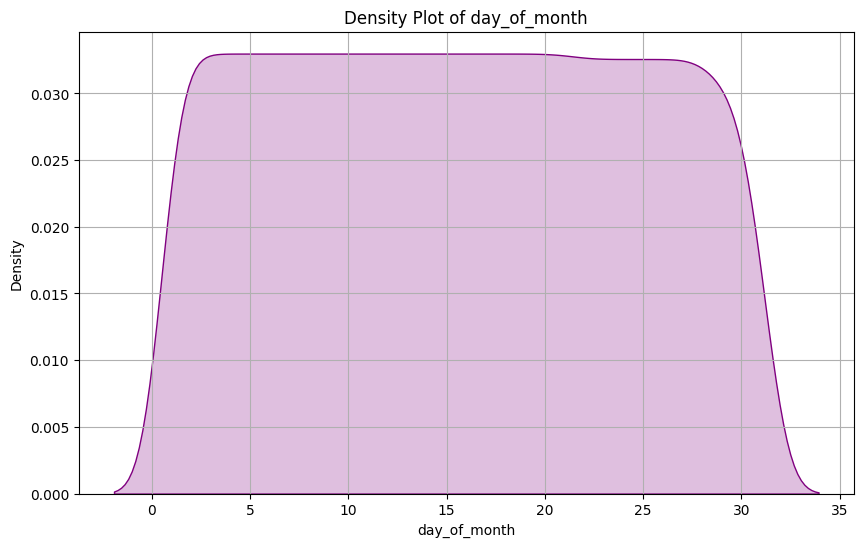

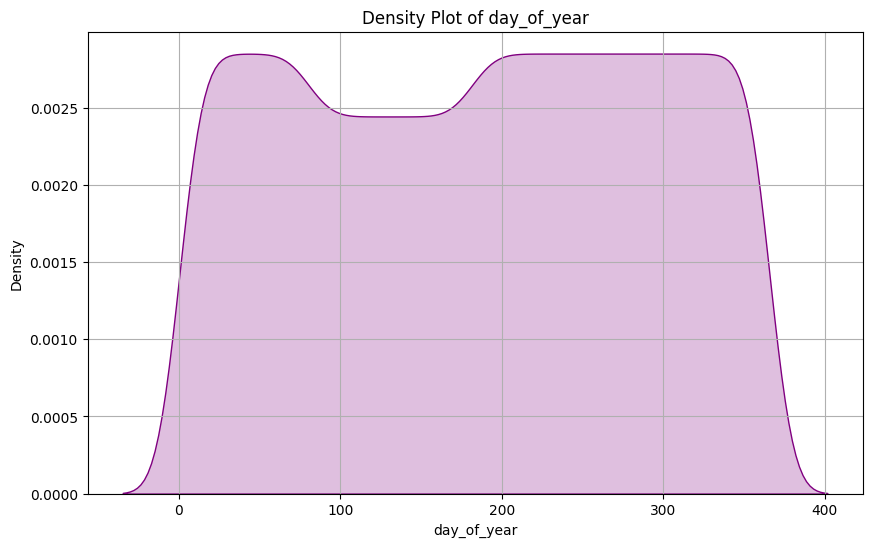

In [175]:


# List of columns to plot
columns_to_plot = ['date', 'megawatthours', 'hour', 'day_of_week', 'day_of_month',
       'day_of_year']

# Loop through each column and plot KDE
for col in columns_to_plot:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(df[col], shade=True, color='purple')
    plt.title(f'Density Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.grid(True)
    plt.show()

In [176]:
df

,date,megawatthours,hour,day_of_week,day_of_month,day_of_year
0,2015-07-01 05:00:00,162827,5,2,1,182
1,2015-07-01 06:00:00,335153,6,2,1,182
2,2015-07-01 07:00:00,333837,7,2,1,182
3,2015-07-01 08:00:00,398386,8,2,1,182
4,2015-07-01 09:00:00,388954,9,2,1,182
...,...,...,...,...,...,...
58931,2022-03-21 16:00:00,433344,16,0,21,80
58932,2022-03-21 17:00:00,429156,17,0,21,80
58933,2022-03-21 18:00:00,426496,18,0,21,80
58934,2022-03-21 19:00:00,423393,19,0,21,80


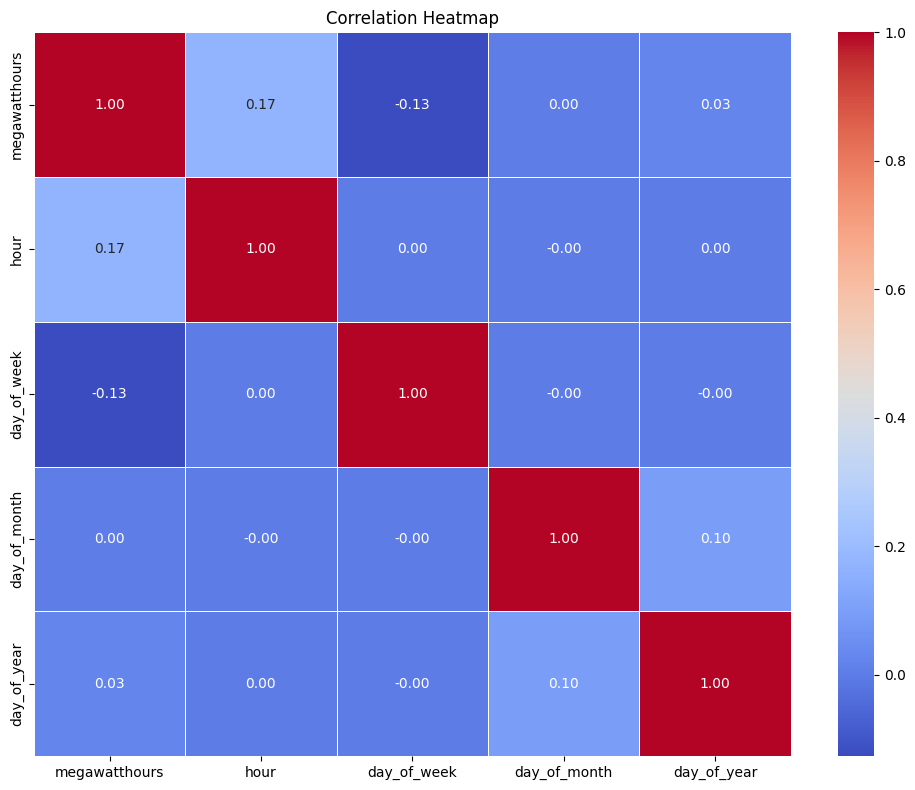

In [177]:
# Compute correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [178]:
# ===== CYCLIC (PERIODIC) FEATURES =====
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['dayofweek_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dayofweek_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['dayofmonth_sin'] = np.sin(2 * np.pi * (df['day_of_month'] - 1) / 31)
df['dayofmonth_cos'] = np.cos(2 * np.pi * (df['day_of_month'] - 1) / 31)
df['dayofyear_sin'] = np.sin(2 * np.pi * (df['day_of_year'] - 1) / 365)
df['dayofyear_cos'] = np.cos(2 * np.pi * (df['day_of_year'] - 1) / 365)


In [179]:
df.head(2)

,date,megawatthours,hour,day_of_week,day_of_month,day_of_year,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos
0,2015-07-01 05:00:00,162827,5,2,1,182,0.965926,2.588190e-01,0.974928,-0.222521,0.0,1.0,0.025818,-0.999667
1,2015-07-01 06:00:00,335153,6,2,1,182,1.000000,6.123234e-17,0.974928,-0.222521,0.0,1.0,0.025818,-0.999667


In [180]:
df.drop(columns=["hour", "day_of_week", "day_of_month", "day_of_year"], axis=1, inplace=True)

In [181]:
df

,date,megawatthours,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos
0,2015-07-01 05:00:00,162827,0.965926,2.588190e-01,0.974928,-0.222521,0.000000,1.000000,0.025818,-0.999667
1,2015-07-01 06:00:00,335153,1.000000,6.123234e-17,0.974928,-0.222521,0.000000,1.000000,0.025818,-0.999667
2,2015-07-01 07:00:00,333837,0.965926,-2.588190e-01,0.974928,-0.222521,0.000000,1.000000,0.025818,-0.999667
3,2015-07-01 08:00:00,398386,0.866025,-5.000000e-01,0.974928,-0.222521,0.000000,1.000000,0.025818,-0.999667
4,2015-07-01 09:00:00,388954,0.707107,-7.071068e-01,0.974928,-0.222521,0.000000,1.000000,0.025818,-0.999667
...,...,...,...,...,...,...,...,...,...,...
58931,2022-03-21 16:00:00,433344,-0.866025,-5.000000e-01,0.000000,1.000000,-0.790776,-0.612106,0.977848,0.209315
58932,2022-03-21 17:00:00,429156,-0.965926,-2.588190e-01,0.000000,1.000000,-0.790776,-0.612106,0.977848,0.209315
58933,2022-03-21 18:00:00,426496,-1.000000,-1.836970e-16,0.000000,1.000000,-0.790776,-0.612106,0.977848,0.209315
58934,2022-03-21 19:00:00,423393,-0.965926,2.588190e-01,0.000000,1.000000,-0.790776,-0.612106,0.977848,0.209315


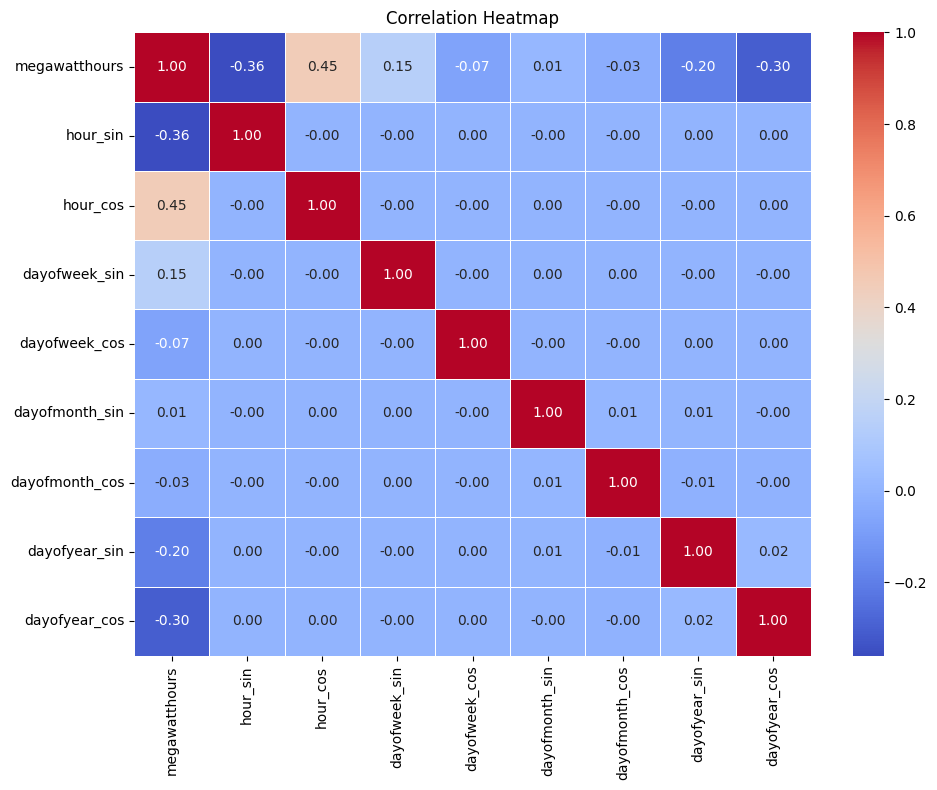

In [182]:
# Compute correlation matrix
corrmatrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corrmatrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()